In [4]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from time import time
from typing import Tuple
from scipy.optimize import curve_fit
import pickle
# from binding import line_sim as sim
from sim import line_sim, cyclic_sim
from Z_utils import *
from numba import njit

In [3]:
q=1

L = 300
T = 100
kon = 1
koff = 1
kstep = 100
kq = 10

In [5]:
@njit
def calc_current(res, dt):
    DT = np.cumsum(dt)
    index = int(len(DT)/100)
    start = DT[-index]
    end = DT[-1] 
    a=np.where(res[-index:]==2)[0]
    return len(a)/(end-start)

In [6]:
Nq=5
Nkon=10

Q = np.linspace(1.1,8,Nq)
KON = np.linspace(0.001,1.3,Nkon)

lamda = np.zeros((Nq,Nkon))
lamda_var = np.zeros_like(lamda)
num_kins = np.zeros_like(lamda)
current = np.zeros_like(lamda)

for i in range(len(Q)):
    for j in range(len(KON)):
        data, times, res, dt = line_sim(L,T, KON[j], koff, kstep, 100, Q[i])
        num_kins[i, j] = np.mean(np.sum(data[200:, :], axis=1))
        lamda[i, j], lamda_var[i, j] = fit_cdf(res, dt, get_stepping_data)
        current[i,j] = calc_current(res,dt)
# semi_current = num_kins*lamda
# M = np.max(semi_current)
# idx = np.where(semi_current==M)[0][0]
semi_current = num_kins*lamda

In [29]:
from joblib import Parallel, delayed

def process_simulation(Q_val, KON_val):
    data, times, res, dt = line_sim(L, T, KON_val, koff, 1, 1, Q_val)
    num_kin = np.mean(np.sum(data[200:, :], axis=1))
    lam, lam_var = fit_cdf(res, dt, get_stepping_data)
    curr = calc_current(res, dt)
    return num_kin, lam, lam_var, curr

Nq = 5
Nkon = 30

Q = np.linspace(1.1, 8, Nq)
KON = np.linspace(0.001, 1.3, Nkon)

lamda = np.zeros((Nq, Nkon))
lamda_var = np.zeros_like(lamda)
num_kins = np.zeros_like(lamda)
current = np.zeros_like(lamda)

results = Parallel(n_jobs=-1)(
    delayed(process_simulation)(Q[i], KON[j]) 
    for i in range(len(Q)) 
    for j in range(len(KON))
)

index = 0
for i in range(len(Q)):
    for j in range(len(KON)):
        num_kins[i, j], lamda[i, j], lamda_var[i, j], current[i, j] = results[index]
        index += 1

semi_current = num_kins * lamda

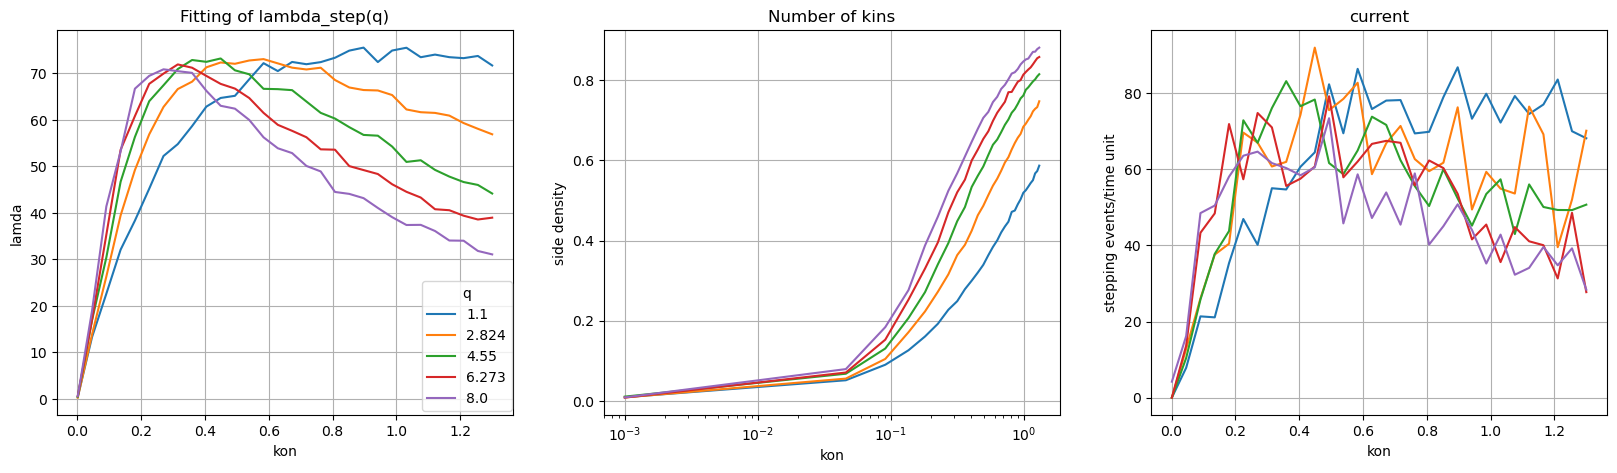

In [33]:
fig, (ax1, ax2,ax4) = plt.subplots(1,3, figsize=(20,5))

ax1.plot(KON, lamda.T, label = Q.astype(np.float16))
ax1.set(xlabel = "kon", ylabel = "lamda", title = "Fitting of lambda_step(q)")
ax1.grid()
ax1.legend(loc = (0.8,0.01),title="q")

ax2.plot(KON, num_kins.T/L)
ax2.set(xlabel = "kon", ylabel = "side density", title = "Number of kins", xscale = "log")
ax2.grid()

semi_current = num_kins*lamda

# ax3.plot(KON, semi_current.T, marker=".")
# ax3.set(xlabel = "kon", ylabel = "", title = "Semi - current kq =100")
# ax3.grid()

ax4.plot(KON, current.T)
ax4.set(xlabel = "kon", ylabel = "stepping events/time unit", title = "current")
ax4.grid()

In [20]:
fig.savefig("new_results.png", dpi = 300)